# Сравнение качества ASR-моделей на собственном датасете

Этот ноутбук предназначен для воспроизводимого сравнения качества моделей распознавания речи в текст на вашем CSV-датасете.

### Что умеет ноутбук
- загружает CSV с разметкой и аудиопутями;
- нормализует пути через `PATH_PREFIX_MAP` для разных окружений;
- чистит референсную транскрипцию от таймкодов, меток спикеров и служебных вставок;
- считает `WER`, `CER`, среднюю/медианную ошибку по строкам, суммарную задержку и `RTF`;
- сохраняет лидерборд и предсказания каждой модели;
- позволяет удобно добавлять новые модели через единый `MODEL_REGISTRY`.

### Модели в сравнении
- `openai/whisper-large-v3-turbo`
- `jonatasgrosman/wav2vec2-large-xlsr-53-russian`
- `t-tech/T-one`
- `ai-sage/GigaAM-v3` в режимах `ctc` и `rnnt`

> Ноутбук сделан так, чтобы модели загружались лениво: в память попадает только та модель, которая сейчас оценивается.


## 1. Установка зависимостей

> Для `T-one` комфортнее Linux / WSL / Kaggle.  
> Если окружение уже подготовлено, эту ячейку можно пропустить.


In [1]:
# %pip install -q -U jiwer

In [2]:

# Базовые зависимости
# %pip install -q -U transformers datasets[audio] accelerate jiwer evaluate librosa soundfile sentencepiece hydra-core omegaconf

# T-one (Python API)
# %pip install -q git+https://github.com/voicekit-team/T-one.git

# Опционально: long-form зависимости для GigaAM, если понадобятся внешние пайплайны сегментации
# %pip install -q pyannote.audio torchcodec


## 2. Импорты


In [1]:
from __future__ import annotations

import gc
import json
import os
import random
import re
import shutil
import tempfile
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, Iterator, List, Optional, Sequence, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from IPython.display import display
from jiwer import cer, process_words, wer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


## 3. Конфиг эксперимента

Главная идея: все параметры собраны в одном месте.  
Здесь же находится `PATH_PREFIX_MAP`, который можно менять под новое окружение.


In [2]:
# -----------------------------
# Пути и источники данных
# -----------------------------
DATA_CSV_CANDIDATES = [
    # "/kaggle/input/datasets/coreytaz332/markup-calls/_updated.csv",
]

# Можно задать конкретный путь вручную:
# DATA_CSV_PATH = "/kaggle/input/your-dataset/Выгрузка_updated.csv"
DATA_CSV_PATH = "node/Выгрузка_updated.csv"

# -----------------------------
# Маппинг путей под другое окружение
# -----------------------------
PATH_PREFIX_MAP = {
    # r"Z:\calls2": "/kaggle/input/datasets/coreytaz332/markup-calls/calls2/calls2",
}

# Пример добавления новых маппингов:
# PATH_PREFIX_MAP.update({
#     r"D:\audio": "/kaggle/input/my-audio/audio",
#     r"\\server\share\calls": "/mnt/storage/calls",
# })

# -----------------------------
# Названия колонок в CSV
# -----------------------------
REFERENCE_COLUMN = "transcription"
ABSOLUTE_PATH_COLUMN = "absolute_path"
ID_COLUMN = "call_id"

# -----------------------------
# Настройки выборки
# -----------------------------
USE_ONLY_EXISTING_AUDIO = True
DROP_EMPTY_REFERENCES = True
MAX_SAMPLES = None  # None -> взять весь датасет
RANDOM_SEED = 42
SHUFFLE_BEFORE_SAMPLE = True

# -----------------------------
# Настройки вычислений
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
DEFAULT_TARGET_SR = 16_000

# -----------------------------
# Куда сохранять результаты
# -----------------------------
RUN_NAME = time.strftime("asr_benchmark_%Y%m%d_%H%M%S")
ARTIFACTS_DIR = Path("kaggle/working/artifacts") / RUN_NAME
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"DEVICE        : {DEVICE}")
print(f"TORCH_DTYPE   : {TORCH_DTYPE}")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR.resolve()}")

DEVICE        : cuda
TORCH_DTYPE   : torch.float16
ARTIFACTS_DIR : D:\project\multicriteria-dialog-audit-ml\kaggle\working\artifacts\asr_benchmark_20260323_165635


## 4. Утилиты

Здесь находится вся "грязная" инфраструктура:
- поиск CSV;
- перенос путей между Windows / Linux / Kaggle;
- очистка и нормализация текста;
- получение длительности аудио;
- подготовка временных чанков для моделей, которым неудобно работать с длинным аудио.


In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)


def locate_csv(explicit_path: Optional[str], candidates: Sequence[str]) -> Path:
    if explicit_path:
        path = Path(explicit_path)
        if not path.exists():
            raise FileNotFoundError(f"DATA_CSV_PATH не найден: {path}")
        return path

    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path

    checked = [str(Path(x).resolve()) for x in candidates]
    raise FileNotFoundError(
        "Не удалось найти CSV-файл. Проверьте DATA_CSV_PATH или DATA_CSV_CANDIDATES:\\n"
        + "\\n".join(checked)
    )


def normalize_path_string(path_value: Any) -> str:
    if path_value is None or (isinstance(path_value, float) and np.isnan(path_value)):
        return ""
    return str(path_value).strip().replace("\\\\", "/")

def normalize_raw_path(x):
    if pd.isna(x):
        return None
    x = str(x).strip().strip('"').strip("'")
    x = x.replace("/", "\\")
    x = re.sub(r"\\+", r"\\", x)
    return x.rstrip("\\")

def apply_path_prefix_map(path_value: Any, path_prefix_map: Dict[str, str]) -> str:
    raw_path = normalize_path_string(path_value)
    if not raw_path:
        return ""

    raw_norm = raw_path.replace("\\\\", "/")
    raw_fold = raw_norm.casefold()

    for src_prefix, dst_prefix in path_prefix_map.items():
        src_norm = normalize_path_string(src_prefix)
        src_fold = src_norm.casefold()
        if raw_fold.startswith(src_fold):
            suffix = raw_norm[len(src_norm):].lstrip("/")
            return str(Path(dst_prefix) / suffix)

    return raw_norm


def resolve_audio_path(raw_path, path_prefix_map=None):
    raw_path = normalize_raw_path(raw_path)
    if raw_path is None:
        return None

    path_prefix_map = path_prefix_map or {}
    raw_lower = raw_path.lower()

    for src_prefix, dst_prefix in path_prefix_map.items():
        src_prefix_norm = normalize_raw_path(src_prefix)
        src_lower = src_prefix_norm.lower()

        if raw_lower == src_lower or raw_lower.startswith(src_lower + "\\"):
            relative_part = raw_path[len(src_prefix_norm):]
            relative_part = relative_part.lstrip("\\/")
            relative_part = relative_part.replace("\\", "/")
            return dst_prefix.rstrip("/") + ("/" + relative_part if relative_part else "")

    if raw_path.startswith("/"):
        return raw_path

    return raw_path.replace("\\", "/")


def file_exists(raw_path, path_prefix_map=None):
    resolved = resolve_audio_path(raw_path, path_prefix_map)
    if resolved is None or pd.isna(resolved):
        return False
    return Path(resolved).exists()


def get_audio_duration_s(audio_path: str) -> Optional[float]:
    try:
        info = sf.info(audio_path)
        return float(info.duration)
    except Exception:
        try:
            return float(librosa.get_duration(path=audio_path))
        except Exception:
            return None


TIMECODE_RE = re.compile(r"\(\d{2}:\d{2}(?::\d{2})?\)")
SPEAKER_RE = re.compile(r"\bспикер\s*\d+\s*:\s*", flags=re.IGNORECASE)
BRACKETS_RE = re.compile(r"\[[^\]]+\]")
MULTISPACE_RE = re.compile(r"\s+")


def strip_transcription_markup(text: Any) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""

    text = str(text)
    text = TIMECODE_RE.sub(" ", text)
    text = SPEAKER_RE.sub(" ", text)
    text = BRACKETS_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


def normalize_text_for_metrics(text: Any) -> str:
    text = strip_transcription_markup(text)
    text = text.lower().replace("ё", "е")
    text = re.sub(r"[^0-9a-zа-я\s]", " ", text, flags=re.IGNORECASE)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


def safe_wer(ref: str, hyp: str) -> float:
    ref = ref or ""
    hyp = hyp or ""
    if not ref and not hyp:
        return 0.0
    if not ref and hyp:
        return 1.0
    return float(wer(ref, hyp))


def safe_cer(ref: str, hyp: str) -> float:
    ref = ref or ""
    hyp = hyp or ""
    if not ref and not hyp:
        return 0.0
    if not ref and hyp:
        return 1.0
    return float(cer(ref, hyp))


def coerce_transcription_output(output: Any) -> str:
    if output is None:
        return ""

    if isinstance(output, str):
        return output.strip()

    if isinstance(output, dict):
        for key in ("text", "transcription", "prediction", "pred_text"):
            if key in output and output[key] is not None:
                return str(output[key]).strip()

        # Иногда remote code возвращает более сложные словари.
        # Попробуем аккуратно вытащить текстовые поля рекурсивно.
        parts = []
        for value in output.values():
            text = coerce_transcription_output(value)
            if text:
                parts.append(text)
        return " ".join(parts).strip()

    if isinstance(output, (list, tuple)):
        parts = []
        for item in output:
            if hasattr(item, "text"):
                parts.append(str(item.text).strip())
            else:
                text = coerce_transcription_output(item)
                if text:
                    parts.append(text)
        return " ".join(parts).strip()

    if hasattr(output, "text"):
        return str(output.text).strip()

    return str(output).strip()


def iter_audio_chunks_to_tempfiles(
    audio_path: str,
    chunk_length_s: float = 22.0,
    overlap_s: float = 0.25,
    target_sr: int = DEFAULT_TARGET_SR,
) -> Iterator[str]:
    audio, sr = librosa.load(audio_path, sr=target_sr, mono=True)
    chunk_size = int(chunk_length_s * sr)
    step_size = int(max(chunk_length_s - overlap_s, 1.0) * sr)

    with tempfile.TemporaryDirectory(prefix="asr_chunks_") as tmp_dir:
        for chunk_idx, start in enumerate(range(0, len(audio), step_size)):
            end = min(start + chunk_size, len(audio))
            if end <= start:
                continue

            chunk = audio[start:end]
            chunk_path = Path(tmp_dir) / f"chunk_{chunk_idx:04d}.wav"
            sf.write(chunk_path, chunk, sr)

            yield str(chunk_path)

            if end >= len(audio):
                break


def maybe_cleanup_torch() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 5. Загрузка и подготовка датасета


In [4]:
csv_path = locate_csv(DATA_CSV_PATH, DATA_CSV_CANDIDATES)
print(f"Используем CSV: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path)
print(raw_df.shape)
display(raw_df.head(3))


Используем CSV: D:\project\multicriteria-dialog-audit-ml\node\Выгрузка_updated.csv
(1000, 12)


,call_id,transcription,fraud,created_at,id,presence_of_blocks,block_analysis_result,call_type,product_type,deep_analytic_enqueued,absolute_path,name_file
0,6b64918a-8a7a-4933-aa11-a56b2ba2806e,(00:00) [шум](00:01) Спикер 1: Алло.(00:03) Сп...,0,2026-03-18 10:40:04.399,21ecb52a-708e-4604-a531-7d73aa39829b,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": ""n/a"", ""3"": ""n/...",cold,unknown,True,Z:\calls2\1773820842.1776908.wav,1773820842.1776908.wav
1,9e059ff2-0d0a-4b88-9af4-9c76bf776872,"(00:00) [шум]\n(00:01) Спикер 1: Сбербанк, здр...",0,2026-03-18 10:39:59.888,ac2071ff-c0a7-4cfa-92e6-0889a47e01eb,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": 0, ""3"": 0, ""4"":...",cold,unknown,True,Z:\calls2\1773820804.1776814.wav,1773820804.1776814.wav
2,d4bd31ec-7ca7-44ff-ac75-37d624ca0d25,(00:00) [шум]\n(00:01) Спикер 2: Алло.\n(00:02...,0,2026-03-18 10:39:28.924,dbc9c39a-e09f-49b9-a14f-0e5c4463d4ca,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": ""n/a"", ""3"": ""n/...",cold,unknown,True,Z:\calls2\1773820804.1776813.wav,1773820804.1776813.wav


In [5]:
required_columns = [REFERENCE_COLUMN, ABSOLUTE_PATH_COLUMN]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise KeyError(f"В CSV отсутствуют обязательные колонки: {missing_columns}")

df = raw_df.copy()

if ID_COLUMN not in df.columns:
    df[ID_COLUMN] = np.arange(len(df))

df["audio_path"] = df[ABSOLUTE_PATH_COLUMN].apply(lambda x: str(resolve_audio_path(x, PATH_PREFIX_MAP)))
df["audio_exists"] = df[ABSOLUTE_PATH_COLUMN].apply(lambda x: file_exists(x, PATH_PREFIX_MAP))
df["reference_raw"] = df[REFERENCE_COLUMN].fillna("").astype(str)
df["reference_clean"] = df["reference_raw"].apply(strip_transcription_markup)
df["reference_norm"] = df["reference_raw"].apply(normalize_text_for_metrics)

if DROP_EMPTY_REFERENCES:
    df = df[df["reference_norm"].astype(bool)].copy()

if USE_ONLY_EXISTING_AUDIO:
    df = df[df["audio_exists"]].copy()

if SHUFFLE_BEFORE_SAMPLE:
    df = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

if MAX_SAMPLES is not None:
    df = df.head(min(MAX_SAMPLES, len(df))).copy()

df["audio_duration_s"] = df["audio_path"].apply(get_audio_duration_s)

print(f"Итоговая выборка для эксперимента: {len(df)}")
display(df)

Итоговая выборка для эксперимента: 1000


,call_id,transcription,fraud,created_at,id,presence_of_blocks,block_analysis_result,call_type,product_type,deep_analytic_enqueued,absolute_path,name_file,audio_path,audio_exists,reference_raw,reference_clean,reference_norm,audio_duration_s
0,20e01bcf-3f67-4e8a-b3be-6484ab63f125,(00:00) [шум]\n(00:01) Спикер 1: Алло\n(00:02)...,10,2026-03-16 21:41:41.612,29d077b0-c0e3-4317-b40d-339f8201103b,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": ""n/a"", ""2"": ""n/a"", ""3"":...",cold,unknown,True,Z:\calls2\1773668174.1683832.wav,1773668174.1683832.wav,Z:/calls2/1773668174.1683832.wav,True,(00:00) [шум]\n(00:01) Спикер 1: Алло\n(00:02)...,"Алло Алло, добрый день Добрый А подскажите, по...",алло алло добрый день добрый а подскажите пожа...,12.02
1,1daffb4c-0a3e-41e8-9c59-7ff2cf5ae05c,(00:00) Спикер 1: Алло\n(00:01) Спикер 2: Алло...,30,2026-03-16 15:57:06.091,d667df4b-abb3-43c5-9624-48a0446175a8,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": ""n/a"", ""3"": ""n/...",cold,unknown,True,Z:\calls2\1773661537.1666927.wav,1773661537.1666927.wav,Z:/calls2/1773661537.1666927.wav,True,(00:00) Спикер 1: Алло\n(00:01) Спикер 2: Алло...,"Алло Алло Алло, Тамара Евгеньевна, доброго дня...",алло алло алло тамара евгеньевна доброго дня з...,20.20
2,3d0d6c3b-9285-4e40-ba62-5b8156d342a4,(00:01) Спикер 1: Алло.\n(00:03) Спикер 2: Слу...,0,2026-03-16 15:46:15.728,9f892a2f-dc1b-447e-b3c7-11e5406a60fe,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": ""n/a"", ""2"": ""n/a"", ""3"":...",cold,unknown,True,Z:\calls2\1773661442.1666660.wav,1773661442.1666660.wav,Z:/calls2/1773661442.1666660.wav,True,(00:01) Спикер 1: Алло.\n(00:03) Спикер 2: Слу...,"Алло. Слушаю. Здравствуйте, а Павел Андреевич?...",алло слушаю здравствуйте а павел андреевич слу...,59.94
3,5e7ab4e5-4f41-4c51-adaf-ecd3f3f6c754,(00:00) Спикер 1: Ну я поняла. Ага.\n(00:02) С...,15,2026-03-16 18:16:03.464,384173da-0936-46fc-b1cf-817cb4ff881a,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": ""n/a"", ""3"": ""n/...",cold,unknown,True,Z:\calls2\1773663986.1672794.wav,1773663986.1672794.wav,Z:/calls2/1773663986.1672794.wav,True,(00:00) Спикер 1: Ну я поняла. Ага.\n(00:02) С...,"Ну я поняла. Ага. Алло. Натали, день добрый. Д...",ну я поняла ага алло натали день добрый да мен...,15.96
4,9bbfb1c9-6fd4-4877-9f18-1256363bd7b8,(00:00) [шум]\n(00:01) Спикер 1: Алло\n(00:02)...,0,2026-03-17 14:13:58.549,fc4afb7c-3819-4932-b0af-b2766ec83430,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": ""n/a"", ""2"": ""n/a"", ""3"":...",cold,unknown,True,Z:\calls2\1773750321.1741463.wav,1773750321.1741463.wav,Z:/calls2/1773750321.1741463.wav,True,(00:00) [шум]\n(00:01) Спикер 1: Алло\n(00:02)...,"Алло Алло, Татьяна, добрый день. Это компания ...",алло алло татьяна добрый день это компания гуд...,35.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,f58b7016-f5af-4aaf-aaaf-e55641cf91d5,(00:00) [шум]\n(00:02) Спикер 1: Алло.\n(00:03...,0,2026-03-18 08:31:42.656,f33c5801-738e-4629-9e89-780b1d952f6e,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": ""n/a"", ""2"": ""n/a"", ""3"":...",cold,unknown,True,Z:\calls2\1773818771.1770806.wav,1773818771.1770806.wav,Z:/calls2/1773818771.1770806.wav,True,(00:00) [шум]\n(00:02) Спикер 1: Алло.\n(00:03...,Алло. Здравствуйте. Звоню в компанию Каркасные...,алло здравствуйте звоню в компанию каркасные б...,10.54
996,91fcd3d8-5939-44d1-8f84-34f88bfcd701,(00:00) [рингтон]\n(00:13) Спикер 1: Компания ...,0,2026-03-17 18:00:59.633,76f789bf-ad4a-4c70-a68d-716b5520c0c4,"{""presentation"": 1, ""next_step_offer"": 1, ""cal...","{""presentation"": {""1"": 0, ""2"": ""n/a"", ""3"": ""n/...",cold,unknown,True,Z:\calls2\1773754636.1751667.wav,1773754636.1751667.wav,Z:/calls2/1773754636.1751667.wav,True,(00:00) [рингтон]\n(00:13) Спикер 1: Ко

## 6. Реестр моделей и адаптеры

Ниже сделана расширяемая схема:

- `MODEL_REGISTRY` — список моделей и их параметров;
- `BaseASRAdapter` — общий интерфейс;
- `TransformersPipelineAdapter` — универсальный адаптер для моделей Hugging Face, которые хорошо работают через `pipeline`;
- `TOneAdapter` и `GigaAMAdapter` — кастомные адаптеры для моделей со своей логикой.

Чтобы добавить новую модель, чаще всего достаточно просто вписать ещё один элемент в `MODEL_REGISTRY`.


In [6]:
@dataclass
class ModelSpec:
    key: str
    label: str
    adapter_cls: type
    init_kwargs: Dict[str, Any] = field(default_factory=dict)
    enabled: bool = True


class BaseASRAdapter:
    def __init__(self, spec: ModelSpec):
        self.spec = spec
        self.device = DEVICE
        self.dtype = TORCH_DTYPE

    def load(self) -> None:
        raise NotImplementedError

    def transcribe(self, audio_path: str) -> str:
        raise NotImplementedError

    def unload(self) -> None:
        maybe_cleanup_torch()


class TransformersPipelineAdapter(BaseASRAdapter):
    def load(self) -> None:
        from transformers import (
            AutoModelForCTC,
            AutoModelForSpeechSeq2Seq,
            AutoProcessor,
            Wav2Vec2Processor,
            pipeline,
        )

        model_id = self.spec.init_kwargs["model_id"]
        model_kind = self.spec.init_kwargs.get("kind", "ctc")
        low_cpu_mem_usage = self.spec.init_kwargs.get("low_cpu_mem_usage", True)

        if model_id == "jonatasgrosman/wav2vec2-large-xlsr-53-russian":
            processor = Wav2Vec2Processor.from_pretrained(model_id)
        else:
            processor = AutoProcessor.from_pretrained(model_id)

        if model_kind == "seq2seq":
            model = AutoModelForSpeechSeq2Seq.from_pretrained(
                model_id,
                dtype=self.dtype,
                low_cpu_mem_usage=low_cpu_mem_usage,
            )
        elif model_kind == "ctc":
            model = AutoModelForCTC.from_pretrained(model_id)
        else:
            raise ValueError(f"Неизвестный kind={model_kind!r}")

        if self.device == "cuda":
            model = model.to("cuda")

        pipe_kwargs = {
            "task": "automatic-speech-recognition",
            "model": model,
            "tokenizer": getattr(processor, "tokenizer", None),
            "feature_extractor": getattr(processor, "feature_extractor", None),
            "device": 0 if self.device == "cuda" else -1,
        }

        if model_kind == "seq2seq":
            pipe_kwargs["dtype"] = self.dtype

        for optional_key in ("chunk_length_s", "stride_length_s", "batch_size"):
            if optional_key in self.spec.init_kwargs:
                pipe_kwargs[optional_key] = self.spec.init_kwargs[optional_key]

        self.pipe = pipeline(**pipe_kwargs)

    def transcribe(self, audio_path: str) -> str:
        call_kwargs = {}

        if "generate_kwargs" in self.spec.init_kwargs:
            call_kwargs["generate_kwargs"] = self.spec.init_kwargs["generate_kwargs"]

        if "return_timestamps" in self.spec.init_kwargs:
            call_kwargs["return_timestamps"] = self.spec.init_kwargs[
                "return_timestamps"
            ]

        result = self.pipe(audio_path, **call_kwargs)
        return coerce_transcription_output(result)

    def unload(self) -> None:
        self.pipe = None
        super().unload()


# class TOneAdapter(BaseASRAdapter):
#     def load(self) -> None:
#         from tone import StreamingCTCPipeline

#         self.pipeline = StreamingCTCPipeline.from_hugging_face()

#     def transcribe(self, audio_path: str) -> str:
#         from tone import read_audio

#         audio = read_audio(audio_path)
#         result = self.pipeline.forward_offline(audio)
#         return coerce_transcription_output(result)

#     def unload(self) -> None:
#         self.pipeline = None
#         super().unload()


class GigaAMAdapter(BaseASRAdapter):
    def load(self) -> None:
        from transformers import AutoModel

        revision = self.spec.init_kwargs["revision"]
        self.model = AutoModel.from_pretrained(
            "ai-sage/GigaAM-v3",
            revision=revision,
            trust_remote_code=True,
        )
        self.model = self.model.to(self.device)

    def _transcribe_single_file(self, audio_path: str) -> str:
        output = self.model.transcribe(audio_path)
        return coerce_transcription_output(output)

    def transcribe(self, audio_path: str) -> str:
        duration_s = get_audio_duration_s(audio_path)
        long_audio_threshold_s = self.spec.init_kwargs.get(
            "long_audio_threshold_s", 24.5
        )
        chunk_long_audio = self.spec.init_kwargs.get("chunk_long_audio", True)

        if duration_s and duration_s > long_audio_threshold_s and chunk_long_audio:
            parts = []
            for chunk_path in iter_audio_chunks_to_tempfiles(
                audio_path=audio_path,
                chunk_length_s=self.spec.init_kwargs.get("chunk_length_s", 22.0),
                overlap_s=self.spec.init_kwargs.get("overlap_s", 0.25),
                target_sr=self.spec.init_kwargs.get("target_sr", DEFAULT_TARGET_SR),
            ):
                parts.append(self._transcribe_single_file(chunk_path))
            return " ".join([part for part in parts if part]).strip()

        return self._transcribe_single_file(audio_path)

    def unload(self) -> None:
        self.model = None
        super().unload()


MODEL_REGISTRY: Dict[str, ModelSpec] = {
    "whisper_large_v3_turbo": ModelSpec(
        key="whisper_large_v3_turbo",
        label="Whisper Large v3 Turbo",
        adapter_cls=TransformersPipelineAdapter,
        init_kwargs={
            "model_id": "openai/whisper-large-v3-turbo",
            "kind": "seq2seq",
            "chunk_length_s": 30,
            "batch_size": 8,
            "generate_kwargs": {
                "task": "transcribe",
                "language": "russian",
            },
        },
        enabled=True,
    ),
    "whisper_large_v3": ModelSpec(
        key="whisper_large_v3",
        label="Whisper Large v3",
        adapter_cls=TransformersPipelineAdapter,
        init_kwargs={
            "model_id": "openai/whisper-large-v3",
            "kind": "seq2seq",
            "chunk_length_s": 30,
            "batch_size": 8,
            "generate_kwargs": {
                "task": "transcribe",
                "language": "russian",
            },
        },
        enabled=True,
    ),
    "wav2vec2_xlsr_53_ru": ModelSpec(
        key="wav2vec2_xlsr_53_ru",
        label="Wav2Vec2 XLSR-53 Russian",
        adapter_cls=TransformersPipelineAdapter,
        init_kwargs={
            "model_id": "jonatasgrosman/wav2vec2-large-xlsr-53-russian",
            "kind": "ctc",
            "chunk_length_s": 20,
            "stride_length_s": (4, 2),
            "batch_size": 8,
        },
        enabled=True,
    ),
    # "t_one": ModelSpec(
    #     key="t_one",
    #     label="T-one",
    #     adapter_cls=TOneAdapter,
    #     init_kwargs={},
    #     enabled=True,
    # ),
    "gigaam_v3_ctc": ModelSpec(
        key="gigaam_v3_ctc",
        label="GigaAM v3 CTC",
        adapter_cls=GigaAMAdapter,
        init_kwargs={
            "revision": "ctc",
            "chunk_long_audio": True,
            "chunk_length_s": 22.0,
            "overlap_s": 0.25,
            "long_audio_threshold_s": 24.5,
        },
        enabled=True,
    ),
    "gigaam_v3_rnnt": ModelSpec(
        key="gigaam_v3_rnnt",
        label="GigaAM v3 RNNT",
        adapter_cls=GigaAMAdapter,
        init_kwargs={
            "revision": "rnnt",
            "chunk_long_audio": True,
            "chunk_length_s": 22.0,
            "overlap_s": 0.25,
            "long_audio_threshold_s": 24.5,
        },
        enabled=True,
    ),
    "gigaam_v3_e2e_ctc": ModelSpec(
        key="gigaam_v3_e2e_ctc",
        label="ai-sage/GigaAM-v3 (e2e_ctc)",
        adapter_cls=GigaAMAdapter,
        init_kwargs={
            "revision": "e2e_ctc",
            "chunk_long_audio": True,
            "chunk_length_s": 22.0,
            "overlap_s": 0.25,
            "long_audio_threshold_s": 24.5,
        },
        enabled=True,
    ),
    "gigaam_v3_e2e_rnnt": ModelSpec(
        key="gigaam_v3_e2e_rnnt",
        label="ai-sage/GigaAM-v3 (e2e_rnnt)",
        adapter_cls=GigaAMAdapter,
        init_kwargs={
            "revision": "e2e_rnnt",
            "chunk_long_audio": True,
            "chunk_length_s": 22.0,
            "overlap_s": 0.25,
            "long_audio_threshold_s": 24.5,
        },
        enabled=True,
    ),
}

selected_specs = [spec for spec in MODEL_REGISTRY.values() if spec.enabled]
print("Выбраны модели:")
for spec in selected_specs:
    print(f" - {spec.label} ({spec.key})")

Выбраны модели:
 - Whisper Large v3 Turbo (whisper_large_v3_turbo)
 - Whisper Large v3 (whisper_large_v3)
 - Wav2Vec2 XLSR-53 Russian (wav2vec2_xlsr_53_ru)
 - GigaAM v3 CTC (gigaam_v3_ctc)
 - GigaAM v3 RNNT (gigaam_v3_rnnt)
 - ai-sage/GigaAM-v3 (e2e_ctc) (gigaam_v3_e2e_ctc)
 - ai-sage/GigaAM-v3 (e2e_rnnt) (gigaam_v3_e2e_rnnt)


### Как добавить новую модель

#### Вариант 1 — обычная Hugging Face модель через `pipeline`


In [9]:

# Пример: добавление новой модели без написания нового класса.
#
# MODEL_REGISTRY["my_new_ctc_model"] = ModelSpec(
#     key="my_new_ctc_model",
#     label="My New CTC Model",
#     adapter_cls=TransformersPipelineAdapter,
#     init_kwargs={
#         "model_id": "org/model-name",
#         "kind": "ctc",          # или "seq2seq"
#         "chunk_length_s": 20,
#         "stride_length_s": (4, 2),
#         "batch_size": 8,
#     },
#     enabled=True,
# )
#
# Для seq2seq-моделей можно добавить generate_kwargs:
# "generate_kwargs": {"task": "transcribe", "language": "russian"}


#### Вариант 2 — если у модели собственный API

Нужно унаследоваться от `BaseASRAdapter` и реализовать три метода:
- `load()`
- `transcribe(audio_path)`
- `unload()`


## 7. Функции оценки


In [7]:
def build_empty_summary(spec: ModelSpec, pred_df: pd.DataFrame) -> Dict[str, Any]:
    return {
        "model_key": spec.key,
        "model_label": spec.label,
        "n_total": len(pred_df),
        "n_ok": 0,
        "n_error": len(pred_df),
        "corpus_wer": np.nan,
        "corpus_cer": np.nan,
        "avg_row_wer": np.nan,
        "median_row_wer": np.nan,
        "avg_row_cer": np.nan,
        "median_row_cer": np.nan,
        "total_audio_sec": np.nan,
        "total_latency_sec": pred_df["latency_sec"].sum(),
        "rtf": np.nan,
    }


def compute_corpus_wer(refs: List[str], hyps: List[str]) -> float:
    corpus_words = process_words(refs, hyps)
    return float(corpus_words.wer)


def compute_corpus_cer(refs: List[str], hyps: List[str]) -> float:
    joined_ref = " ".join(refs).strip()
    joined_hyp = " ".join(hyps).strip()
    return safe_cer(joined_ref, joined_hyp)


def build_summary(spec: ModelSpec, pred_df: pd.DataFrame) -> Dict[str, Any]:
    ok_df = pred_df[pred_df["status"] == "ok"].copy()

    if ok_df.empty:
        return build_empty_summary(spec, pred_df)

    refs = ok_df["reference_norm"].fillna("").tolist()
    hyps = ok_df["prediction_norm"].fillna("").tolist()

    corpus_wer_value = compute_corpus_wer(refs, hyps)
    corpus_cer_value = compute_corpus_cer(refs, hyps)

    total_audio_sec = ok_df["audio_duration_s"].fillna(0).sum()
    total_latency_sec = ok_df["latency_sec"].sum()

    return {
        "model_key": spec.key,
        "model_label": spec.label,
        "n_total": len(pred_df),
        "n_ok": len(ok_df),
        "n_error": len(pred_df) - len(ok_df),
        "corpus_wer": corpus_wer_value,
        "corpus_cer": corpus_cer_value,
        "avg_row_wer": ok_df["row_wer"].mean(),
        "median_row_wer": ok_df["row_wer"].median(),
        "avg_row_cer": ok_df["row_cer"].mean(),
        "median_row_cer": ok_df["row_cer"].median(),
        "total_audio_sec": total_audio_sec,
        "total_latency_sec": total_latency_sec,
        "rtf": (total_latency_sec / total_audio_sec) if total_audio_sec > 0 else np.nan,
    }

In [ ]:
def evaluate_model(
    spec: ModelSpec, eval_df: pd.DataFrame
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    adapter = spec.adapter_cls(spec)
    adapter.load()

    rows: List[Dict[str, Any]] = []

    try:
        iterator = tqdm(
            eval_df.itertuples(index=False),
            total=len(eval_df),
            desc=spec.label,
        )

        for row in iterator:
            audio_path = getattr(row, "audio_path")
            ref_raw = getattr(row, "reference_raw")
            ref_clean = getattr(row, "reference_clean")
            ref_norm = getattr(row, "reference_norm")
            audio_duration_s = getattr(row, "audio_duration_s")
            sample_id = getattr(row, ID_COLUMN)

            started_at = time.perf_counter()
            error_message = None
            pred_raw = ""

            try:
                pred_raw = adapter.transcribe(audio_path)
            except Exception as exc:
                error_message = f"{type(exc).__name__}: {exc}"

            latency_sec = time.perf_counter() - started_at
            pred_norm = normalize_text_for_metrics(pred_raw)

            rows.append(
                {
                    "sample_id": sample_id,
                    "model_key": spec.key,
                    "model_label": spec.label,
                    "audio_path": audio_path,
                    "audio_duration_s": audio_duration_s,
                    "reference_raw": ref_raw,
                    "reference_clean": ref_clean,
                    "reference_norm": ref_norm,
                    "prediction_raw": pred_raw,
                    "prediction_norm": pred_norm,
                    "row_wer": safe_wer(ref_norm, pred_norm),
                    "row_cer": safe_cer(ref_norm, pred_norm),
                    "latency_sec": latency_sec,
                    "status": "ok" if error_message is None else "error",
                    "error_message": error_message,
                }
            )
    finally:
        adapter.unload()

    pred_df = pd.DataFrame(rows)
    summary = build_summary(spec, pred_df)

    return summary, pred_df

## 8. Запуск эксперимента


In [13]:
all_predictions: Dict[str, pd.DataFrame] = {}

In [17]:
for spec in selected_specs:
    print(f"===== {spec.label} =====")

    pred_path = PREDICTIONS_DIR / f"{spec.key}.parquet"

    if pred_path.exists():
        print(f"Пропуск: результат уже существует -> {pred_path}")
        continue

    summary, pred_df = evaluate_model(spec, df)

    all_predictions[spec.key] = pred_df

    pred_df.to_parquet(pred_path, index=False)

    print(json.dumps(summary, ensure_ascii=False, indent=2))
    print(f"Сохранены предсказания: {pred_path}")

===== Wav2Vec2 XLSR-53 Russian =====
Пропуск: результат уже существует -> kaggle\working\artifacts\asr_benchmark_20260323_142940\predictions\wav2vec2_xlsr_53_ru.parquet
===== GigaAM v3 CTC =====


GigaAM v3 CTC:   0%|          | 0/1000 [00:00<?, ?it/s]

{
  "model_key": "gigaam_v3_ctc",
  "model_label": "GigaAM v3 CTC",
  "n_total": 1000,
  "n_ok": 1000,
  "n_error": 0,
  "corpus_wer": 0.17612062598098052,
  "corpus_cer": 0.10781420843990386,
  "avg_row_wer": 0.18148944911722822,
  "median_row_wer": 0.16447026183457603,
  "avg_row_cer": 0.11302961995574703,
  "median_row_cer": 0.09439150825645193,
  "total_audio_sec": 86361.41999999998,
  "total_latency_sec": 565.2835947000531,
  "rtf": 0.006545556970925828
}
Сохранены предсказания: kaggle\working\artifacts\asr_benchmark_20260323_142940\predictions\gigaam_v3_ctc.parquet
===== GigaAM v3 RNNT =====


GigaAM v3 RNNT:   0%|          | 0/1000 [00:00<?, ?it/s]

{
  "model_key": "gigaam_v3_rnnt",
  "model_label": "GigaAM v3 RNNT",
  "n_total": 1000,
  "n_ok": 1000,
  "n_error": 0,
  "corpus_wer": 0.16366794386483244,
  "corpus_cer": 0.11224368885741948,
  "avg_row_wer": 0.16930965794164313,
  "median_row_wer": 0.15427114322141947,
  "avg_row_cer": 0.11799627775600302,
  "median_row_cer": 0.09913908738384997,
  "total_audio_sec": 86361.41999999998,
  "total_latency_sec": 2067.24748419995,
  "rtf": 0.02393716412027443
}
Сохранены предсказания: kaggle\working\artifacts\asr_benchmark_20260323_142940\predictions\gigaam_v3_rnnt.parquet
===== ai-sage/GigaAM-v3 (e2e_ctc) =====


ai-sage/GigaAM-v3 (e2e_ctc):   0%|          | 0/1000 [00:00<?, ?it/s]

{
  "model_key": "gigaam_v3_e2e_ctc",
  "model_label": "ai-sage/GigaAM-v3 (e2e_ctc)",
  "n_total": 1000,
  "n_ok": 1000,
  "n_error": 0,
  "corpus_wer": 0.1717985412242637,
  "corpus_cer": 0.09686863286273717,
  "avg_row_wer": 0.17572512762927284,
  "median_row_wer": 0.16455696202531644,
  "avg_row_cer": 0.09680958174546052,
  "median_row_cer": 0.08533863090314703,
  "total_audio_sec": 86361.41999999998,
  "total_latency_sec": 464.53096730007746,
  "rtf": 0.0053789176613825655
}
Сохранены предсказания: kaggle\working\artifacts\asr_benchmark_20260323_142940\predictions\gigaam_v3_e2e_ctc.parquet
===== ai-sage/GigaAM-v3 (e2e_rnnt) =====


ai-sage/GigaAM-v3 (e2e_rnnt):   0%|          | 0/1000 [00:00<?, ?it/s]

{
  "model_key": "gigaam_v3_e2e_rnnt",
  "model_label": "ai-sage/GigaAM-v3 (e2e_rnnt)",
  "n_total": 1000,
  "n_ok": 1000,
  "n_error": 0,
  "corpus_wer": 0.16222532545471333,
  "corpus_cer": 0.10362652871503644,
  "avg_row_wer": 0.16577375360740088,
  "median_row_wer": 0.15603043186395166,
  "avg_row_cer": 0.10554812485825506,
  "median_row_cer": 0.09350878049177261,
  "total_audio_sec": 86361.41999999998,
  "total_latency_sec": 1945.477554500023,
  "rtf": 0.022527160328072688
}
Сохранены предсказания: kaggle\working\artifacts\asr_benchmark_20260323_142940\predictions\gigaam_v3_e2e_rnnt.parquet


In [14]:
for spec in selected_specs:
    pred_path = PREDICTIONS_DIR / f"{spec.key}.parquet"

    if not pred_path.exists():
        print(f"Пропуск summary: нет файла {pred_path}")
        continue

    pred_df = pd.read_parquet(pred_path)

    all_predictions[spec.key] = pred_df

Пропуск summary: нет файла kaggle\working\artifacts\asr_benchmark_20260323_165635\predictions\whisper_large_v3.parquet


## 9. Лидерборд


In [8]:
all_summaries: List[Dict[str, Any]] = []

In [10]:
for spec in selected_specs:
    pred_path = PREDICTIONS_DIR / f"{spec.key}.parquet"

    if not pred_path.exists():
        print(f"Пропуск summary: нет файла {pred_path}")
        continue

    pred_df = pd.read_parquet(pred_path)
    summary = build_summary(spec, pred_df)
    all_summaries.append(summary)
    print(f"Собран summary для {spec.label}")

leaderboard = pd.DataFrame(all_summaries).sort_values(
    by=["corpus_wer", "corpus_cer", "rtf"],
    ascending=[True, True, True],
    na_position="last",
).reset_index(drop=True)

leaderboard_path = ARTIFACTS_DIR / "leaderboard.csv"
leaderboard.to_csv(leaderboard_path, index=False)

display(leaderboard)
print(f"Лидерборд сохранён: {leaderboard_path}")

Собран summary для Whisper Large v3 Turbo:
Пропуск summary: нет файла kaggle\working\artifacts\asr_benchmark_20260323_165635\predictions\whisper_large_v3.parquet
Собран summary для Wav2Vec2 XLSR-53 Russian:
Собран summary для GigaAM v3 CTC:
Собран summary для GigaAM v3 RNNT:
Собран summary для ai-sage/GigaAM-v3 (e2e_ctc):
Собран summary для ai-sage/GigaAM-v3 (e2e_rnnt):


,model_key,model_label,n_total,n_ok,n_error,corpus_wer,corpus_cer,avg_row_wer,median_row_wer,avg_row_cer,median_row_cer,total_audio_sec,total_latency_sec,rtf
0,gigaam_v3_e2e_rnnt,ai-sage/GigaAM-v3 (e2e_rnnt),1000,1000,0,0.162225,0.103627,0.165774,0.156030,0.105548,0.093509,86361.42,1945.477555,0.022527
1,gigaam_v3_rnnt,GigaAM v3 RNNT,1000,1000,0,0.163668,0.112244,0.169310,0.154271,0.117996,0.099139,86361.42,2067.247484,0.023937
2,gigaam_v3_e2e_ctc,ai-sage/GigaAM-v3 (e2e_ctc),1000,1000,0,0.171799,0.096869,0.175725,0.164557,0.096810,0.085339,86361.42,464.530967,0.005379
3,gigaam_v3_ctc,GigaAM v3 CTC,1000,1000,0,0.176121,0.107814,0.181489,0.164470,0.113030,0.094392,86361.42,565.283595,0.006546
4,whisper_large_v3_turbo,Whisper Large v3 Turbo,1000,1000,0,0.254137,0.181169,0.254899,0.219405,0.181536,0.136859,86361.42,3702.384801,0.042871
5,wav2vec2_xlsr_53_ru,Wav2Vec2 XLSR-53 Russian,1000,1000,0,0.598317,0.280996,0.635098,0.626825,0.304344,0.282937,86361.42,2402.352306,0.027817


Лидерборд сохранён: kaggle\working\artifacts\asr_benchmark_20260323_165635\leaderboard.csv


## 10. Визуализация результатов


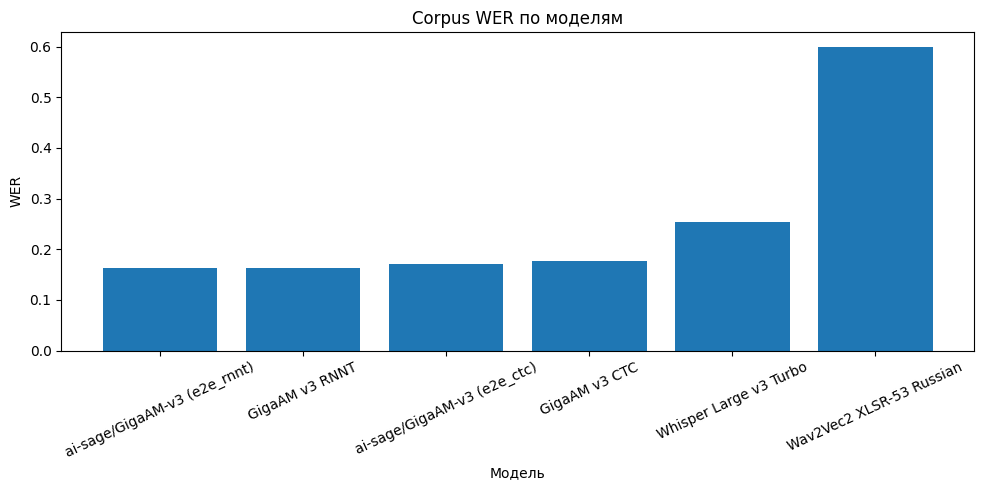

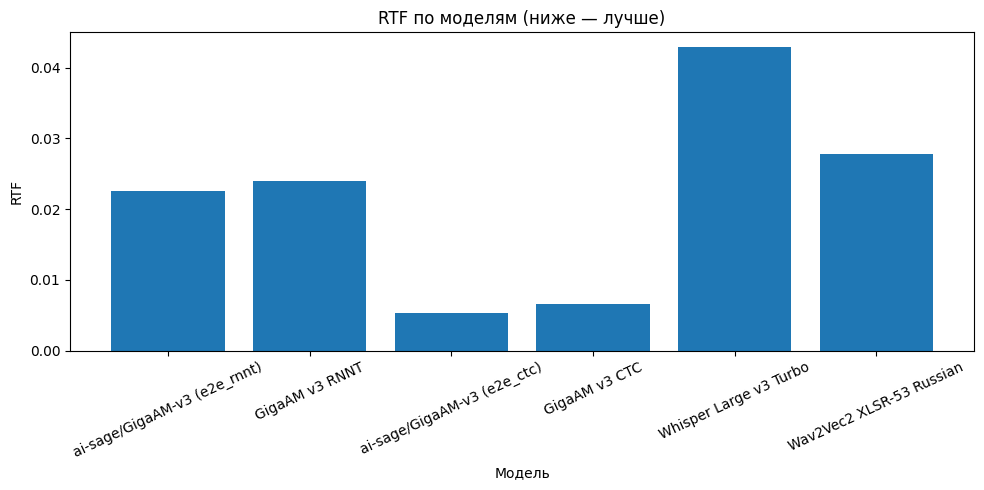

In [11]:
plot_df = leaderboard.dropna(subset=["corpus_wer"]).copy()

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["model_label"], plot_df["corpus_wer"])
    ax.set_title("Corpus WER по моделям")
    ax.set_ylabel("WER")
    ax.set_xlabel("Модель")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["model_label"], plot_df["rtf"])
    ax.set_title("RTF по моделям (ниже — лучше)")
    ax.set_ylabel("RTF")
    ax.set_xlabel("Модель")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
else:
    print("Нет корректных результатов для построения графиков.")


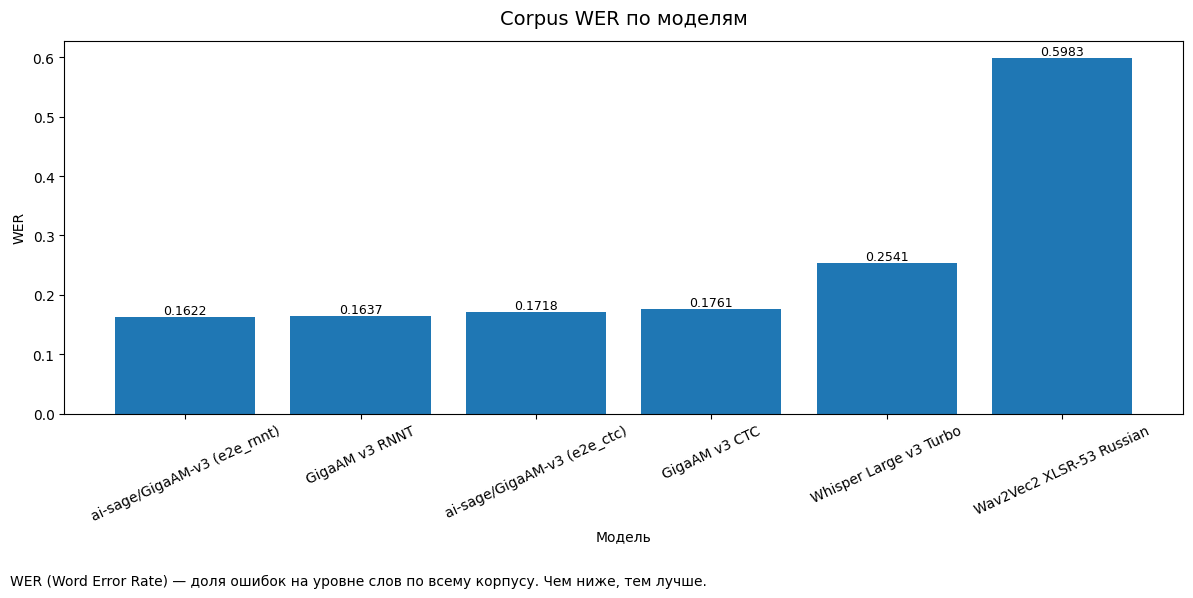

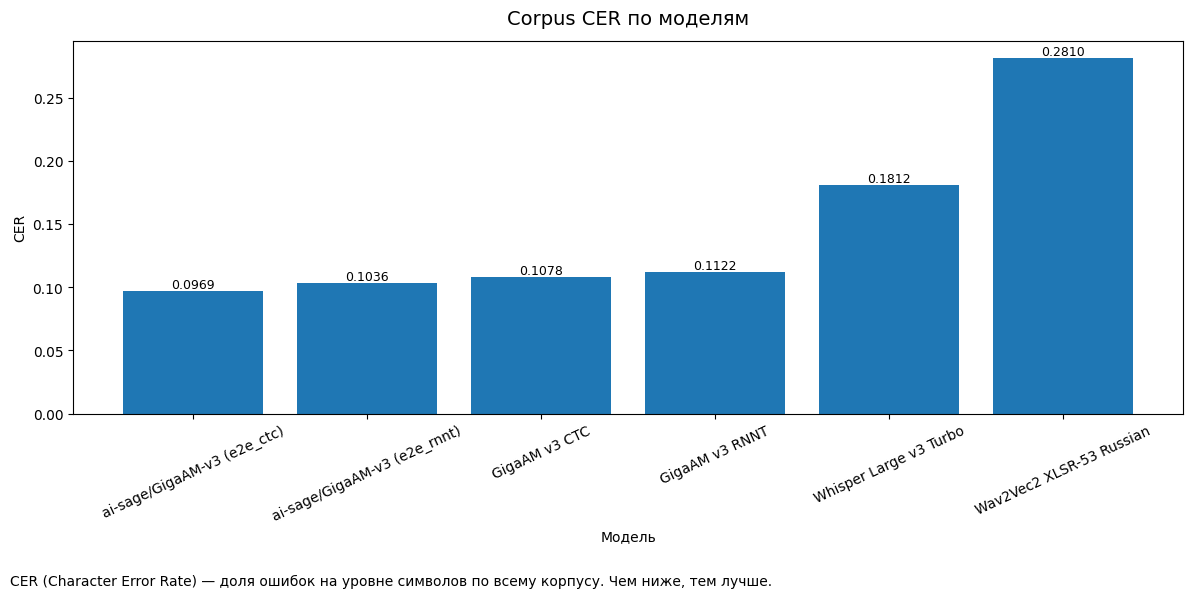

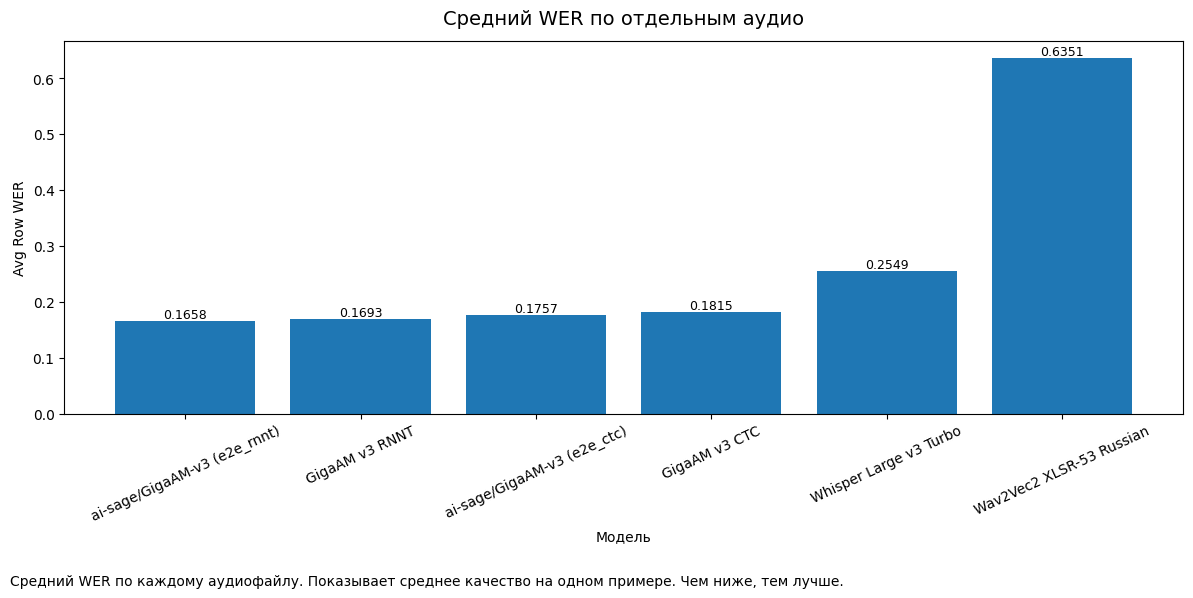

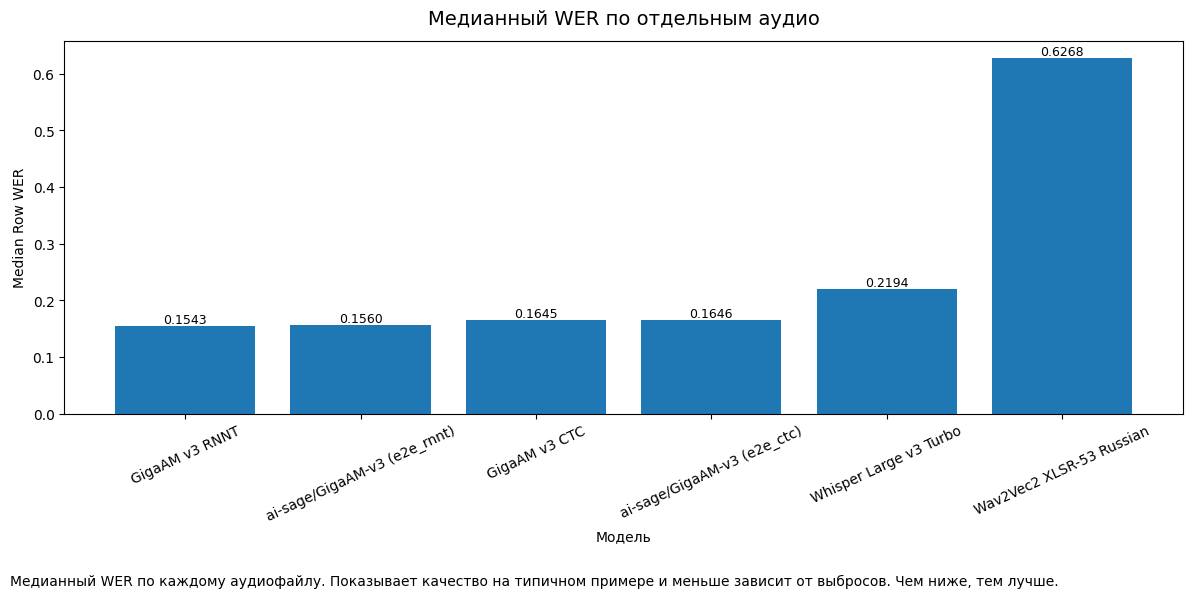

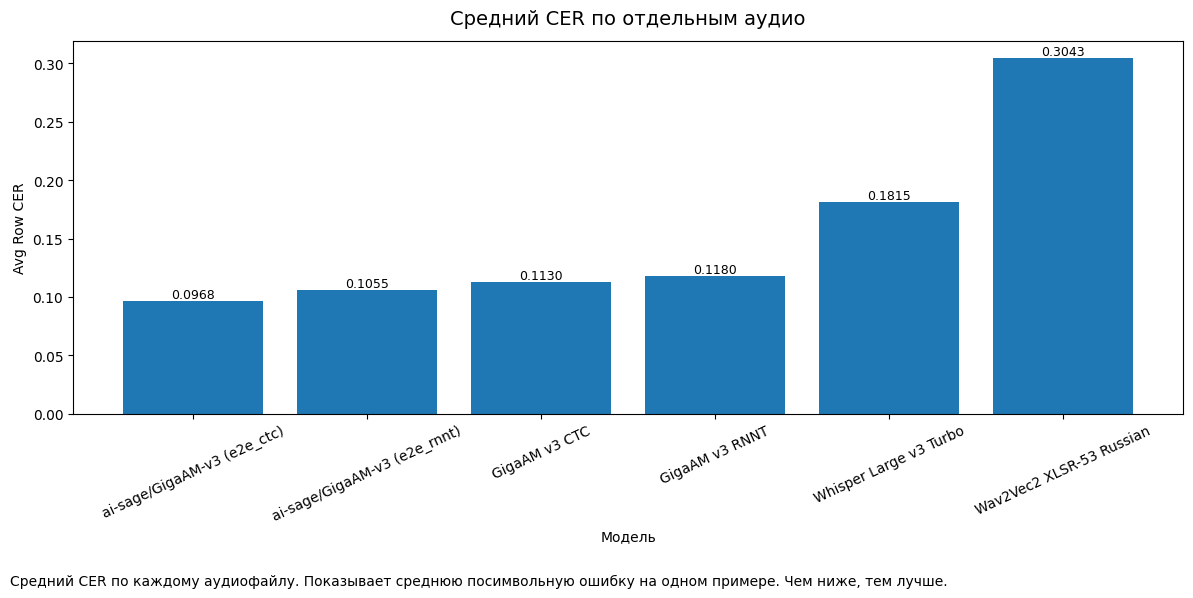

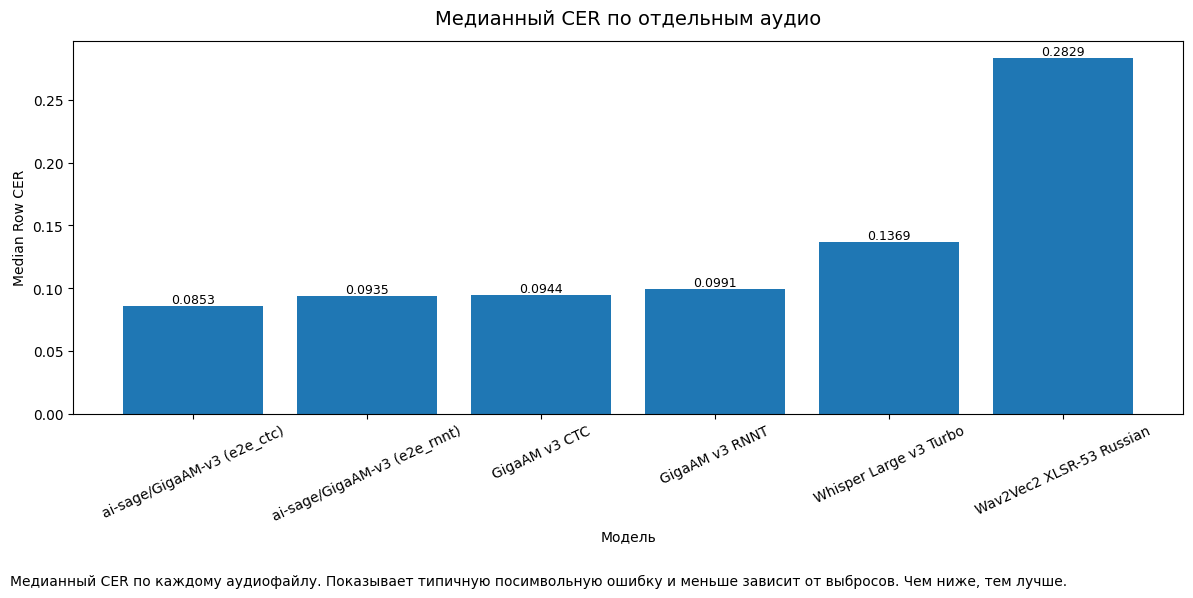

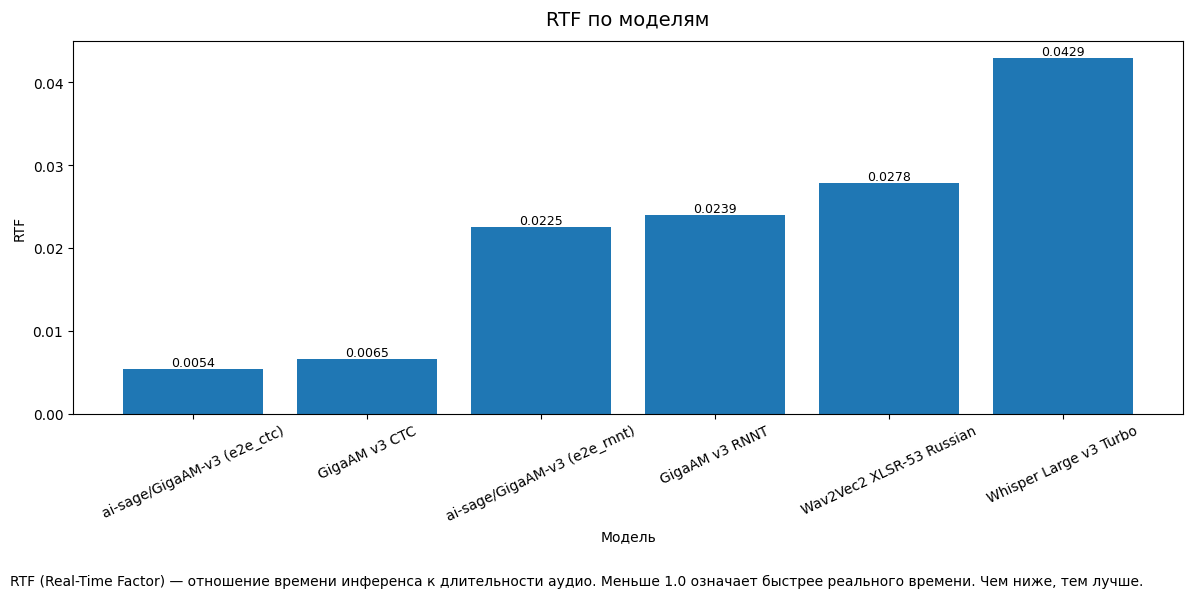

In [17]:
metric_columns = [
    "corpus_wer",
    "corpus_cer",
    "avg_row_wer",
    "median_row_wer",
    "avg_row_cer",
    "median_row_cer",
    "rtf",
]

metric_meta = {
    "corpus_wer": {
        "title": "Corpus WER по моделям",
        "ylabel": "WER",
        "description": "WER (Word Error Rate) — доля ошибок на уровне слов по всему корпусу. Чем ниже, тем лучше.",
    },
    "corpus_cer": {
        "title": "Corpus CER по моделям",
        "ylabel": "CER",
        "description": "CER (Character Error Rate) — доля ошибок на уровне символов по всему корпусу. Чем ниже, тем лучше.",
    },
    "avg_row_wer": {
        "title": "Средний WER по отдельным аудио",
        "ylabel": "Avg Row WER",
        "description": "Средний WER по каждому аудиофайлу. Показывает среднее качество на одном примере. Чем ниже, тем лучше.",
    },
    "median_row_wer": {
        "title": "Медианный WER по отдельным аудио",
        "ylabel": "Median Row WER",
        "description": "Медианный WER по каждому аудиофайлу. Показывает качество на типичном примере и меньше зависит от выбросов. Чем ниже, тем лучше.",
    },
    "avg_row_cer": {
        "title": "Средний CER по отдельным аудио",
        "ylabel": "Avg Row CER",
        "description": "Средний CER по каждому аудиофайлу. Показывает среднюю посимвольную ошибку на одном примере. Чем ниже, тем лучше.",
    },
    "median_row_cer": {
        "title": "Медианный CER по отдельным аудио",
        "ylabel": "Median Row CER",
        "description": "Медианный CER по каждому аудиофайлу. Показывает типичную посимвольную ошибку и меньше зависит от выбросов. Чем ниже, тем лучше.",
    },
    "rtf": {
        "title": "RTF по моделям",
        "ylabel": "RTF",
        "description": "RTF (Real-Time Factor) — отношение времени инференса к длительности аудио. Меньше 1.0 означает быстрее реального времени. Чем ниже, тем лучше.",
    },
}

plot_df = leaderboard.copy()
available_metrics = [col for col in metric_columns if col in plot_df.columns]

if not plot_df.empty and available_metrics:
    for metric in available_metrics:
        metric_df = plot_df.dropna(subset=[metric]).copy()

        if metric_df.empty:
            print(f"Нет корректных значений для метрики: {metric}")
            continue

        metric_df = metric_df.sort_values(metric, ascending=True)
        meta = metric_meta[metric]

        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.bar(metric_df["model_label"], metric_df[metric])

        ax.set_title(meta["title"], fontsize=14, pad=12)
        ax.set_ylabel(meta["ylabel"])
        ax.set_xlabel("Модель")
        ax.tick_params(axis="x", rotation=25)

        for bar in bars:
            value = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        fig.text(
            0.01,
            0.01,
            meta["description"],
            ha="left",
            va="bottom",
            fontsize=10,
        )

        plt.tight_layout(rect=[0, 0.06, 1, 1])
        plt.show()
else:
    print("Нет корректных результатов для построения графиков.")

## 11. Анализ ошибок

Ниже можно посмотреть худшие кейсы по каждой модели и вручную сравнить референс с предсказанием.


In [15]:
TOP_K_ERRORS = 10

for model_key, pred_df in all_predictions.items():
    print(f"\n### {model_key}")
    view_df = (
        pred_df[pred_df["status"] == "ok"]
        .sort_values("row_wer", ascending=False)
        .head(TOP_K_ERRORS)
        [
            [
                "sample_id",
                "audio_path",
                "audio_duration_s",
                "row_wer",
                "row_cer",
                "reference_clean",
                "prediction_raw",
            ]
        ]
    )
    display(view_df)



### whisper_large_v3_turbo


,sample_id,audio_path,audio_duration_s,row_wer,row_cer,reference_clean,prediction_raw
558,849ccaf2-69e5-453e-801c-9b0a4aebc5fe,/kaggle/input/datasets/coreytaz332/markup-call...,89.82,2.653061,1.987915,Для улучшения качества разговор может быть зап...,"Компания Лока, добрый день. Девушка, добрый де..."
975,fd8a7ff9-c0b8-435e-b6e2-cdbc923012d0,/kaggle/input/datasets/coreytaz332/markup-call...,56.80,2.422222,2.843100,"Стоматология Адмирал, чем могу помочь? Да, дев...","Стоматология Адмирал, чем могу помочь? Да, дев..."
304,25357b45-60f2-4039-be28-73ba166d914e,/kaggle/input/datasets/coreytaz332/markup-call...,93.98,2.035398,0.718702,"Алло, здравствуйте. Добрый день. Меня Андрей з...","Алло, здравствуйте. Добрый день. Меня Андрей з..."
68,d23a3e77-7c85-43db-8061-e37e4a028fae,/kaggle/input/datasets/coreytaz332/markup-call...,118.90,1.548387,2.058691,"Тюменский центр имплантации, администратор Вал...",Вечеринский центр имплантации администратор Ва...
282,84647031-2c48-484a-959c-cc2052b97c05,/kaggle/input/datasets/coreytaz332/markup-call...,110.62,1.400000,1.268585,Здравствуйте. Вас приветствует Флэт. В целях у...,Здравствуйте. Вас приветствует ФЛЭД. В целях у...
521,2948f655-6c28-42e1-a8cd-7d569cf7d3e7,/kaggle/input/datasets/coreytaz332/markup-call...,138.00,1.329670,0.909524,Здравствуйте. Нажмите 1 для соединения с секре...,Здравствуйте. Нажмите 1 для соединения с секре...
151,798c9743-df1a-4355-93d2-aa26f684004c,/kaggle/input/datasets/coreytaz332/markup-call...,132.28,1.212121,0.473934,Добрый день. Вы позвонили в официальный дилерс...,"Добрый день, вы позвонили в официальный дилерс..."
802,e5ea6182-7be5-4ddb-874e-0d2bc899b0dc,/kaggle/input/datasets/coreytaz332/markup-call...,61.58,1.209524,0.940532,Завод окон Анна слушаю вас Здравствуйте Анна. ...,ЗВОНОК В ДВЕРЬ ЗВОНОК В ДВЕРЬ ЗВОНОК В ДВЕРЬ З...
681,700d9aba-f4ca-40c0-ab32-6b3bbfbe30e0,/kaggle/input/datasets/coreytaz332/markup-call...,89.82,1.118280,0.845345,Добрый день! Вас приветствует Тойота Восток на...,"Добрый день, вас приветствует Тойота Восток на..."
662,5328fc3a-3c2e-464c-b159-eaf6baeaf72b,/kaggle/input/datasets/coreytaz332/markup-call...,94.30,1.020408,0.827993,"Сауна, здравствуйте. Да, здравствуйте. А, деву...","Сауна, здравствуйте. Да, здравствуйте. Девушка..."



### wav2vec2_xlsr_53_ru


,sample_id,audio_path,audio_duration_s,row_wer,row_cer,reference_clean,prediction_raw
521,2948f655-6c28-42e1-a8cd-7d569cf7d3e7,Z:/calls2/1773663809.1672297.wav,138.00,1.461538,1.071429,Здравствуйте. Нажмите 1 для соединения с секре...,здравствуйте нажмите один для соединения секре...
662,5328fc3a-3c2e-464c-b159-eaf6baeaf72b,Z:/calls2/1773644974.1629588.wav,94.30,1.408163,0.986509,"Сауна, здравствуйте. Да, здравствуйте. А, деву...",сам надрастите да здравстве а девушка самедежи...
245,85618575-b01d-4d56-a8e6-30ce57269f70,Z:/calls2/1773818658.1770470.wav,12.96,1.307692,1.235294,"Алло. Здравствуйте, звоню по поводу компании п...",едопренпотобопыттегудем навода теворет здравс...
160,faf725f6-be80-4434-9e4e-734947f3a39c,Z:/calls2/1773666075.1678211.wav,156.20,1.304000,1.545806,"Ортодонт-центр, администратор Надежда, здравст...",мртодон центр-администратора надежд отратвытя ...
452,99d18210-07ca-4415-8f52-2b35fe3f930b,Z:/calls2/1773750897.1742911.wav,83.10,1.232143,1.029570,Здравствуйте. Вы позвонили в компанию Модуль. ...,в гравствуте вы позвонили в компанию модуль дл...
892,2e49efb1-6e8b-43cd-9442-a30d327d9298,Z:/calls2/1773661893.1667894.wav,83.82,1.217391,0.804989,"Алло, добрый день, Барсмед беспокоит вас, проп...",олодобр день барсибеспокоет вас напучен зенок ...
391,73b9d768-7a7d-4209-b687-2bd28d2401e8,Z:/calls2/1773819918.1774330.wav,66.24,1.215686,1.166667,"Да. А, здравствуйте, представляю отдел новостр...",да рязле пескосявяет под нудерсновопощёподир ...
528,9ffeb2d9-8154-44fb-af7f-242ec8231626,Z:/calls2/1773665090.1675853.wav,114.98,1.000000,0.809717,"Добрый день, стоматология Золотое сечение, адм...",добрый виньскомо того детлаот уесчени админист...
10,2f76c6db-67d0-4553-86ac-e5ce1da0c684,Z:/calls2/1773658274.1658717.wav,399.70,0.991955,1.164357,──────────────────────────────── Вероятность ф...,холо алованита я э с рабочим рывеонил мм в...
236,4f5e9e14-2bce-499e-8516-84ad95e3df54,Z:/calls2/1773756867.1755844.wav,78.88,0.944444,0.739450,"Стоматологическая клиника Виталий Дмитриевич, ...",дите иданкд матологическа некобетали дне потяк...



### gigaam_v3_ctc


...

,sample_id,audio_path,audio_duration_s,row_wer,row_cer,reference_clean,prediction_raw
521,2948f655-6c28-42e1-a8cd-7d569cf7d3e7,Z:/calls2/1773663809.1672297.wav,138.00,1.241758,0.969841,Здравствуйте. Нажмите 1 для соединения с секре...,здравствуйте нажмите один для соединения с сек...
10,2f76c6db-67d0-4553-86ac-e5ce1da0c684,Z:/calls2/1773658274.1658717.wav,399.70,0.985519,1.129330,──────────────────────────────── Вероятность ф...,алло алло ваня это с рабочего звоню видел вопр...
662,5328fc3a-3c2e-464c-b159-eaf6baeaf72b,Z:/calls2/1773644974.1629588.wav,94.30,0.969388,0.768971,"Сауна, здравствуйте. Да, здравствуйте. А, деву...",здравствуйте да здравствуйте девушка сориентир...
428,eaa71cc2-77b3-43f4-a0ca-bbcf2389ce9d,Z:/calls2/1773664813.1675046.wav,62.44,0.564706,0.534979,"Добрый день. Компания ТСС Кавказ, официальный ...",добрый день компания кавказ официальный дилер ...
690,0a735431-7de7-4c8f-bbde-26ff8a90c960,Z:/calls2/1773661122.1665857.wav,38.92,0.509804,0.597015,"Стоматология Интерстом, здравствуйте. День доб...",стоматологи интерстон здравствуйте день добрый...
210,c08f2780-b2a6-4168-9893-abf19f9a4562,Z:/calls2/1773819487.1773093.wav,33.24,0.500000,0.329087,──────────────────────────────── Вероятность ф...,алло алло здравствуйте здравствуйте меня зовут...
208,257148e7-bd42-4ec4-9117-7ce9dd9f418d,Z:/calls2/1773669138.1686271.wav,40.04,0.500000,0.468293,"Информируем, что разговор записывается. ...пос...",информируем что разговор записывается и послед...
42,df0fc54d-0cfe-4423-9a26-6913485af43f,Z:/calls2/1773753252.1748498.wav,10.84,0.476190,0.360360,"…чё ты думал? Слушаю. Алло, добрый день. Подск...",слушаю алло добрый день подскажите пожалуйста ...
236,4f5e9e14-2bce-499e-8516-84ad95e3df54,Z:/calls2/1773756867.1755844.wav,78.88,0.455556,0.544954,"Стоматологическая клиника Виталий Дмитриевич, ...",стоматологическая клиника виталий дмитриев это...
920,fc3cd5b6-9fa5-488e-b877-12b1378b778c,Z:/calls2/1773812669.1761550.wav,70.38,0.450704,0.466960,"Слушаю. Алло, Светлана, добрый день. Добрый. М...",слушаю алло светлана добрый день добрый меня г...



### gigaam_v3_e2e_ctc


,sample_id,audio_path,audio_duration_s,row_wer,row_cer,reference_clean,prediction_raw
521,2948f655-6c28-42e1-a8cd-7d569cf7d3e7,Z:/calls2/1773663809.1672297.wav,138.00,1.219780,0.892063,Здравствуйте. Нажмите 1 для соединения с секре...,Здравствуйте. Нажмите один для соединения с се...
10,2f76c6db-67d0-4553-86ac-e5ce1da0c684,Z:/calls2/1773658274.1658717.wav,399.70,0.983910,1.159738,──────────────────────────────── Вероятность ф...,"Алло? Алло, Ваня, это я. Привет.. С рабочего з..."
662,5328fc3a-3c2e-464c-b159-eaf6baeaf72b,Z:/calls2/1773644974.1629588.wav,94.30,0.979592,0.787521,"Сауна, здравствуйте. Да, здравствуйте. А, деву...","Аанна, здравствуйте. Да, здравствуйте. Аа, дев..."
208,257148e7-bd42-4ec4-9117-7ce9dd9f418d,Z:/calls2/1773669138.1686271.wav,40.04,0.571429,0.482927,"Информируем, что разговор записывается. ...пос...","Информируем, что разговор записывается Так зам..."
42,df0fc54d-0cfe-4423-9a26-6913485af43f,Z:/calls2/1773753252.1748498.wav,10.84,0.523810,0.405405,"…чё ты думал? Слушаю. Алло, добрый день. Подск...","Слушаю.— Алло, добрый день.— Подскажите, пожал..."
838,ee8bf689-f448-4dfe-a7bb-570c6deb1f90,Z:/calls2/1773665401.1676625.wav,72.36,0.453608,0.359300,Здравствуйте. Вы обратились в компанию Алкон. ...,Здравствуйте. Вы обратились в компанию Алкон. ...
355,df0bd776-4c36-4d8f-9f11-66deff2a47a8,Z:/calls2/1773818227.1769319.wav,38.80,0.448980,0.341256,"Алло. Да, здравствуйте, Виктория. Здравствуйте...","Алло. Здравствуйте, Виктория. Здравствуйте. Ви..."
391,73b9d768-7a7d-4209-b687-2bd28d2401e8,Z:/calls2/1773819918.1774330.wav,66.24,0.431373,0.234973,"Да. А, здравствуйте, представляю отдел новостр...","Да. Здравствуйте, представляем. Скажите, пожал..."
573,c31cbe5b-455d-4ca6-bc22-4e701ba2635a,Z:/calls2/1773819867.1774175.wav,12.28,0.421053,0.296296,"Алло. Алексей, добрый день. Здравствуйте. Миха...","Алло. Алексей, добрый день. Здравствуйте, Миха..."
281,f5f214e3-d484-49d1-8be5-4196cb01aae8,Z:/calls2/1773659164.1660735.wav,12.84,0.416667,0.214592,"Компания Экотерем, Максим, здравствуйте. Макси...","Компания Екатерина, Максим, здравствуйте! Макс..."



### gigaam_v3_e2e_rnnt


,sample_id,audio_path,audio_duration_s,row_wer,row_cer,reference_clean,prediction_raw
521,2948f655-6c28-42e1-a8cd-7d569cf7d3e7,Z:/calls2/1773663809.1672297.wav,138.00,1.175824,0.866667,Здравствуйте. Нажмите 1 для соединения с секре...,Здравствуйте. Нажмите один для соединения с се...
10,2f76c6db-67d0-4553-86ac-e5ce1da0c684,Z:/calls2/1773658274.1658717.wav,399.70,0.986323,1.122017,──────────────────────────────── Вероятность ф...,"Алло? Алло, Ваня? Привет. С рабочего звоню. Ви..."
662,5328fc3a-3c2e-464c-b159-eaf6baeaf72b,Z:/calls2/1773644974.1629588.wav,94.30,0.928571,0.740304,"Сауна, здравствуйте. Да, здравствуйте. А, деву...","Здравствуйте. Да, здравствуйте. Девушка, сорие..."
208,257148e7-bd42-4ec4-9117-7ce9dd9f418d,Z:/calls2/1773669138.1686271.wav,40.04,0.607143,0.602439,"Информируем, что разговор записывается. ...пос...","Информируем, что разговор записывается. Алло. ..."
42,df0fc54d-0cfe-4423-9a26-6913485af43f,Z:/calls2/1773753252.1748498.wav,10.84,0.523810,0.378378,"…чё ты думал? Слушаю. Алло, добрый день. Подск...","Слушаю. Алло, добрый день. Подскажите, пожалуй..."
573,c31cbe5b-455d-4ca6-bc22-4e701ba2635a,Z:/calls2/1773819867.1774175.wav,12.28,0.473684,0.392593,"Алло. Алексей, добрый день. Здравствуйте. Миха...","— Алло. — Алексей, добрый день! — Михаил, комп..."
524,e4ae461b-ba5d-4355-9e5e-2637823b577a,Z:/calls2/1773749269.1738591.wav,27.76,0.439024,0.400778,"Алло. Алло. Алло, день добрый. По вопросу, здр...","Алло. Алло, день добрый. По вопросу. Клиентов ..."
340,52d725f7-7245-4865-9617-4d8d74c1cfaf,Z:/calls2/1773670910.1689220.wav,40.04,0.413793,0.199405,"Алло. Алло, здравствуйте. Здравствуйте. Подска...","Алло. Алло, здравствуйте. Здравствуйте. Скажит..."
391,73b9d768-7a7d-4209-b687-2bd28d2401e8,Z:/calls2/1773819918.1774330.wav,66.24,0.411765,0.295082,"Да. А, здравствуйте, представляю отдел новостр...","Да. Здравствуйте, представляем взнос. Что? Вас..."
210,c08f2780-b2a6-4168-9893-abf19f9a4562,Z:/calls2/1773819487.1773093.wav,33.24,0.402439,0.250531,──────────────────────────────── Вероятность ф...,"Алло? Алло, здравствуйте! Здравствуйте. Меня з..."
